In [41]:
import pandas as pd
from pathlib import Path
import glob
import json

import matplotlib.pyplot as plt

In [42]:
SOURCES_TO_COMPARE = ["control_random", "control_hard_coded", "control_online_stg_aug_sep_gym", "control_online_stg_aug_sep_gym_comfort_band", "control_online_stg_aug_sep_gym_comfort_band_greedy", "control_online_stg_aug_sep_gym_comfort_band_greedy_1h", "control_online_stg_aug_sep_gym_comfort_band_greedy_5h"]
name_to_label = {
    "control_hard_coded": "Rule-Based Control",
    "control_random": "Random Control",
    "control_online_stg_aug_sep_gym": "Deep Q-Learning",
    "control_online_stg_aug_sep_gym_comfort_band": "Deep Q-Learning\nComfort Band",
    "control_online_stg_aug_sep_gym_comfort_band_greedy_1h": "Deep Q-Learning\nComfort Band\nGreedy (1h)",
    "control_online_stg_aug_sep_gym_comfort_band_greedy": "Deep Q-Learning\nComfort Band\nGreedy (2.5h)",
    "control_online_stg_aug_sep_gym_comfort_band_greedy_5h": "Deep Q-Learning\nComfort Band\nGreedy (5h)",
}

name_to_short_label = {
    "control_online_stg_aug_sep_gym": "DQL",
    "control_hard_coded": "Rule-B.",
    "control_random": "Rand.",
    "control_online_stg_aug_sep_gym_comfort_band": "DQL\nComf.",
    "control_online_stg_aug_sep_gym_comfort_band_greedy_1h": "DQL\nComf.G1",
    "control_online_stg_aug_sep_gym_comfort_band_greedy": "DQL\nComf.G2.5",
    "control_online_stg_aug_sep_gym_comfort_band_greedy_5h": "DQL\nComf.G5",
}

CONTROL_ACTIONS = {
    "all_closed": 0, # for winter night
    "all_open": 2, # for summer night
    "inside_open": 1, # for winter day (with radiation)
    "outside_open": -1 # for summer day
}

In [43]:
FOLDER_PATH = Path(r"C:\Users\lkclu\Documents\GitHub\DTFS\results\control\simulation\stg_oct_new")

files = glob.glob(str(FOLDER_PATH / "*.jsonl"))

dfs = []
for f in files:
    with open(f) as fh:
        records = [json.loads(line) for line in fh]
    
    df = pd.json_normalize(records)
    df.columns = [c.split(".")[-1] for c in df.columns]
    df["source"] = Path(f).stem
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

start_date = pd.Timestamp("2024-01-01")
data["datetime"] = start_date + pd.to_timedelta(data["current_time"], unit="h")

data = data[data["source"].isin(SOURCES_TO_COMPARE)]

In [44]:
data.head()

,control,hour_of_day,current_time,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,source,datetime
0,0,0.166667,6552.166667,7.458333,0.0,20.848033,control_hard_coded,2024-09-30 00:10:00.000000001
1,0,0.333333,6552.333333,7.375000,0.0,20.567003,control_hard_coded,2024-09-30 00:19:59.999999998
2,0,0.500000,6552.500000,7.291667,0.0,20.328061,control_hard_coded,2024-09-30 00:30:00.000000000
3,0,0.666667,6552.666667,7.208333,0.0,20.124367,control_hard_coded,2024-09-30 00:40:00.000000001
4,0,0.833333,6552.833333,7.125000,0.0,19.950179,control_hard_coded,2024-09-30 00:49:59.999999998


In [45]:
WEEK_NUMBER = 101

week_length = 24*3

week_interval = ((WEEK_NUMBER - 1) * week_length, WEEK_NUMBER * week_length)

print(week_interval)

filtered_data = data[(data['current_time'] >= week_interval[0]) & (data['current_time'] < week_interval[1])]

filtered_data.head()


(7200, 7272)


,control,hour_of_day,current_time,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,source,datetime
3887,2,0.000000,7200.000000,9.083333,0.0,21.142991,control_hard_coded,2024-10-27 00:00:00.000000000
3888,2,0.166667,7200.166667,8.916667,0.0,20.916182,control_hard_coded,2024-10-27 00:10:00.000000001
3889,2,0.333333,7200.333333,8.750000,0.0,20.721621,control_hard_coded,2024-10-27 00:19:59.999999998
3890,2,0.500000,7200.500000,8.583333,0.0,20.550680,control_hard_coded,2024-10-27 00:30:00.000000000
3891,0,0.666667,7200.666667,8.416667,0.0,20.397279,control_hard_coded,2024-10-27 00:40:00.000000001


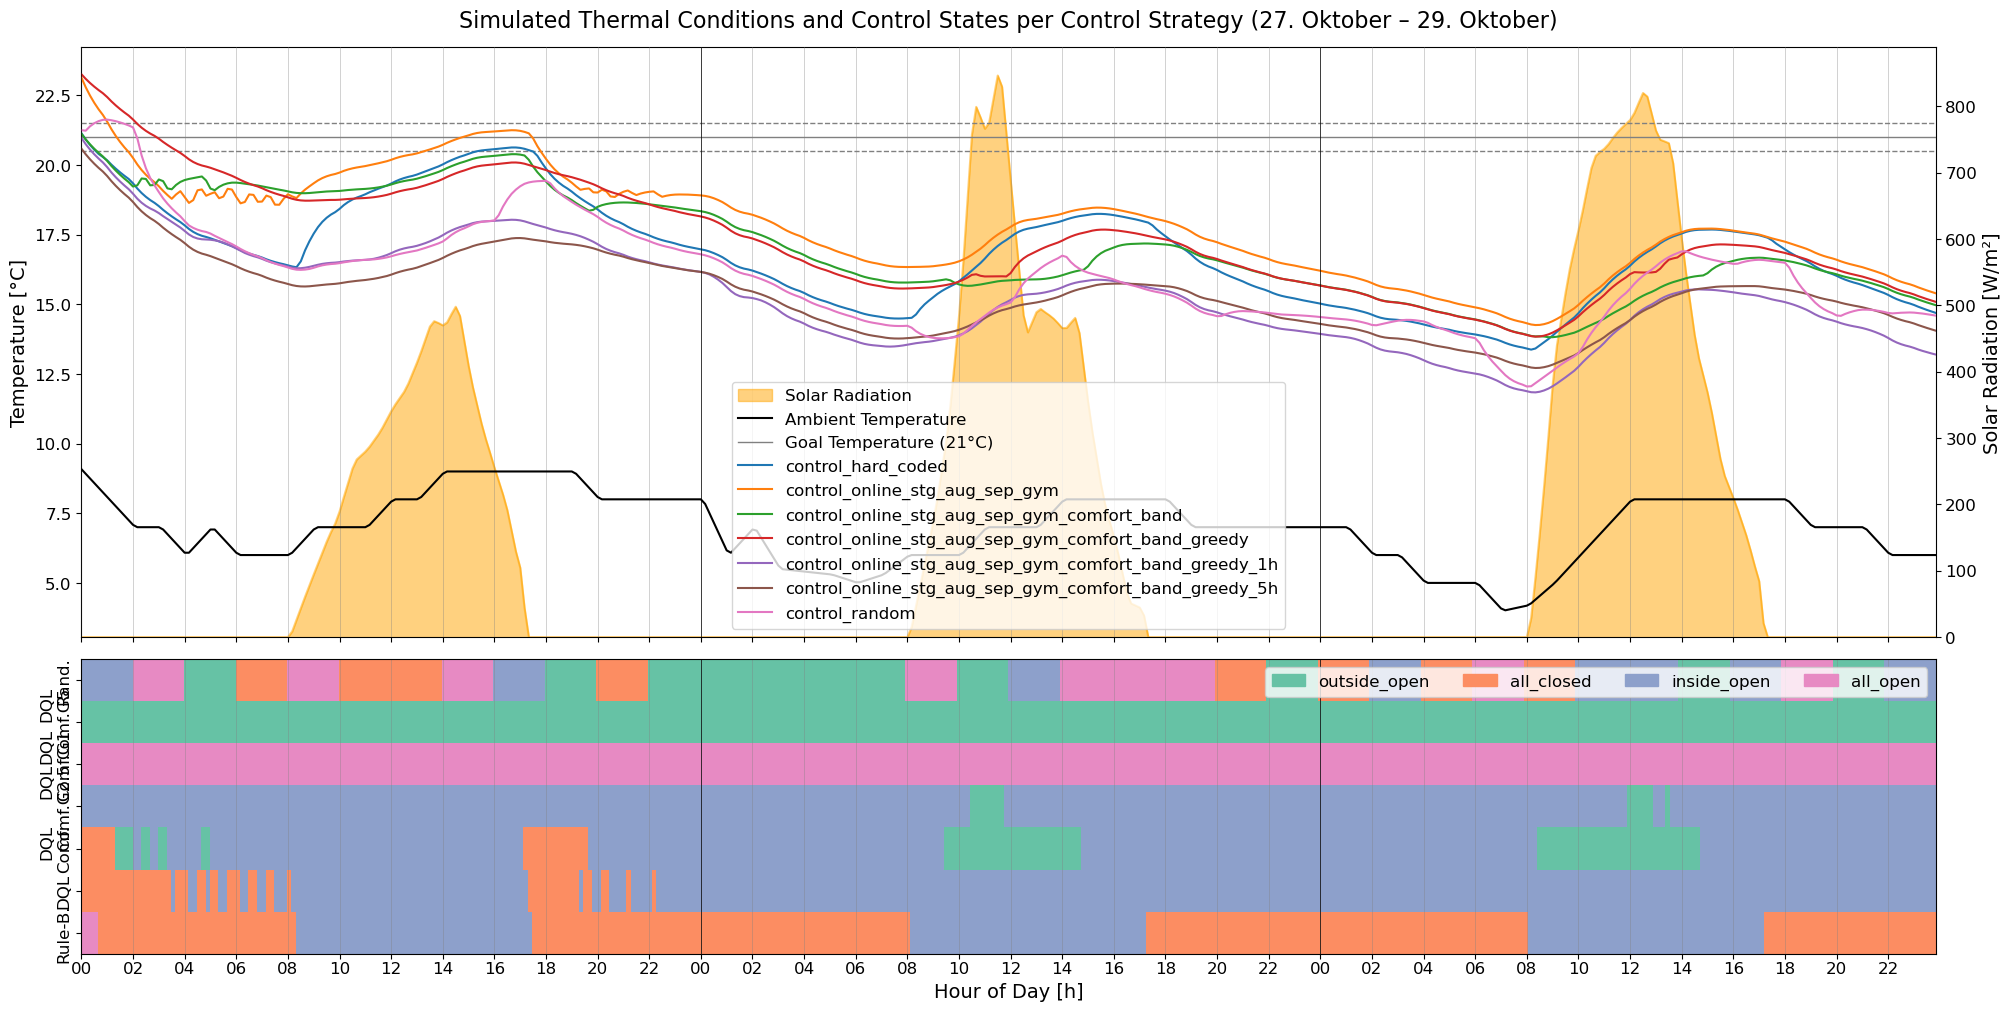

In [46]:
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import locale

locale.setlocale(locale.LC_TIME, "de_DE.UTF-8")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [2, 1]})
ax1_rad = ax1.twinx()

colors = {source: color for source, color in zip(filtered_data['source'].unique(), plt.cm.tab10.colors)}

# Plot dry bulb once
first_source = filtered_data['source'].unique()[0]
filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="dry_bulb_temperature",
    ax=ax1, color="black", label="Ambient Temperature"
)

# Radiation on second y-axis (once, same across sources)
filtered_data[filtered_data['source'] == first_source].plot(
    kind="area", x="datetime", y="total_horizontal_radiation",
    ax=ax1_rad, color="orange", label="Solar Radiation", alpha=0.5
)

ax1_rad.set_zorder(ax1.get_zorder() - 1)
ax1.set_frame_on(False)

# Goal temperature line
ax1.axhline(y=21, color="gray", linestyle="-", linewidth=1, label="Goal Temperature (21°C)")
ax1.axhline(y=20.5, color="gray", linestyle="--", linewidth=1)
ax1.axhline(y=21.5, color="gray", linestyle="--", linewidth=1)

source_labels = {
    "deep_rl": "Deep Q-Learning",
    "hard_coded": "Rule-Based Control",
    "random": "Random Control",
}

for source, subset in filtered_data.groupby('source'):
    color = colors[source]
    subset.plot(kind="line", x="datetime", y="operative_temperature", ax=ax1, color=color, label=f"{source_labels.get(source, source)}")

ax1.set_ylabel("Temperature [°C]")
lines1, labels1 = ax1.get_legend_handles_labels()
lines_rad, labels_rad = ax1_rad.get_legend_handles_labels()
ax1.legend(lines_rad + lines1, labels_rad + labels1, loc="best")
ax1_rad.set_ylabel("Solar Radiation [W/m²]")
ax1_rad.get_legend().remove()

# --------------------------------------------------------------------------
# Control state as colored bands (one row per source)
# --------------------------------------------------------------------------
control_labels = {v: k for k, v in CONTROL_ACTIONS.items()}
state_values = sorted(control_labels.keys())
state_colors = plt.cm.Set2.colors[:len(state_values)]

cmap = mcolors.ListedColormap(state_colors)
bounds = [state_values[0] - 0.5] + [
    (state_values[i] + state_values[i + 1]) / 2 for i in range(len(state_values) - 1)
] + [state_values[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sources = filtered_data['source'].unique()

for i, source in enumerate(sources):
    subset = filtered_data[filtered_data['source'] == source].sort_values('datetime')
    t = mdates.date2num(subset['datetime'].values)
    c = subset['control'].values.reshape(1, -1)

    ax2.imshow(
        c, aspect='auto', cmap=cmap, norm=norm,
        extent=[t[0], t[-1], i, i + 1],
        interpolation='nearest',
        origin='lower'
    )

ax2.set_ylim(0, len(sources))
ax2.set_yticks([i + 0.5 for i in range(len(sources))])

ax2.set_yticklabels([name_to_short_label.get(source, source) for source in sources], rotation=90, va='center')
ax2.set_ylabel("")

# Legend built manually since imshow doesn't auto-generate one
legend_patches = [
    mpatches.Patch(color=state_colors[j], label=control_labels[val])
    for j, val in enumerate(state_values)
]
ax2.legend(handles=legend_patches, loc="upper right", ncol=len(state_values))

# Split x-axis: hours on top, days on bottom
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H"))

# Hour gridlines
ax1.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax2.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)

# Day gridlines
day_ticks = mdates.DayLocator().tick_values(filtered_data['datetime'].min(), filtered_data['datetime'].max())
for day in day_ticks:
    ax1.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')
    ax2.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')

ax2.tick_params(axis='x', which='both', rotation=0)

# Force render first, then set minor locator/formatter
# Dates as minor ticks
ax2.xaxis.set_minor_locator(mdates.DayLocator())
ax2.xaxis.set_minor_formatter(
    mdates.DateFormatter("%d. %B")
)

# Hour labels
ax2.tick_params(
    axis="x",
    which="major",
    rotation=0,
    pad=2
)

# Date labels
ax2.tick_params(
    axis="x",
    which="minor",
    rotation=0,
    pad=18
)

for label in ax2.xaxis.get_majorticklabels():
    label.set_ha("center")

for label in ax2.xaxis.get_minorticklabels():
    label.set_ha("center")

ax2.set_xlabel("Hour of Day [h]")
ax1.set_xlabel("")

start_date = filtered_data["datetime"].min().strftime("%d. %B")
end_date = filtered_data["datetime"].max().strftime("%d. %B")

plt.title(
    f"Simulated Thermal Conditions and Control States per Control Strategy "
    f"({start_date} – {end_date})",
    y=1.02
)

plt.show()

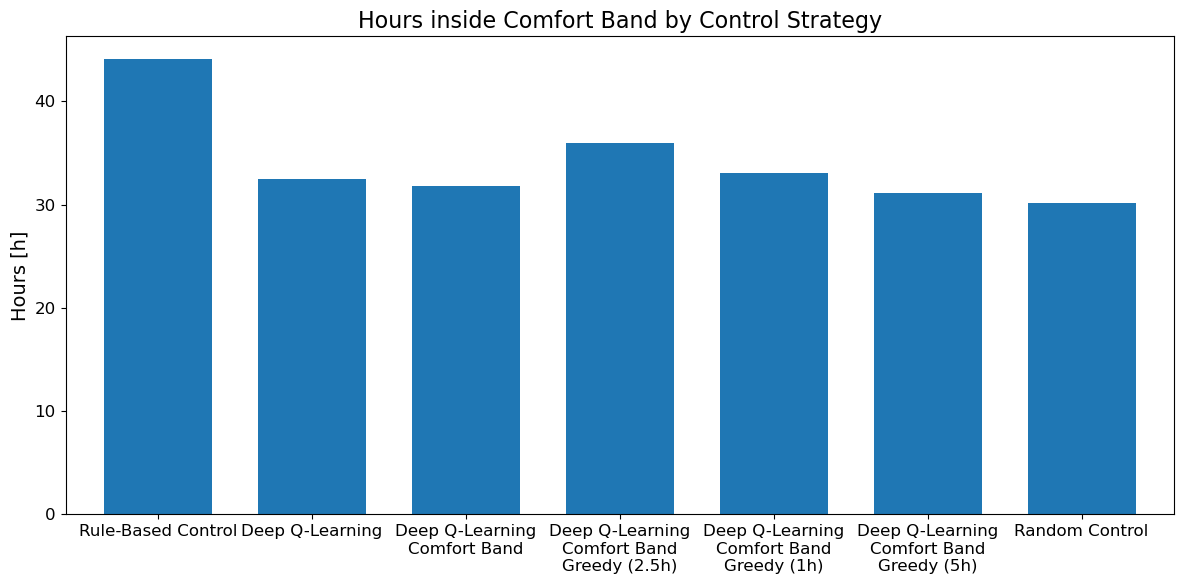

In [47]:
T_HIGH = 21.5
T_LOW = 20.5

# comfort mask
data["comfort"] = data["operative_temperature"].between(T_LOW, T_HIGH)

# aggregate
comfort_hours = data.groupby("source")["comfort"].sum() / 12

# build clean summary dataframe
summary = pd.DataFrame({
    "Comfort hours": comfort_hours
}).sort_index()

summary.index = summary.index.map(name_to_label)

# plot
summary.plot(kind="bar", figsize=(12, 6), width=0.7)

plt.ylabel("Hours [h]")
plt.xlabel("")
plt.title("Hours inside Comfort Band by Control Strategy")
plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

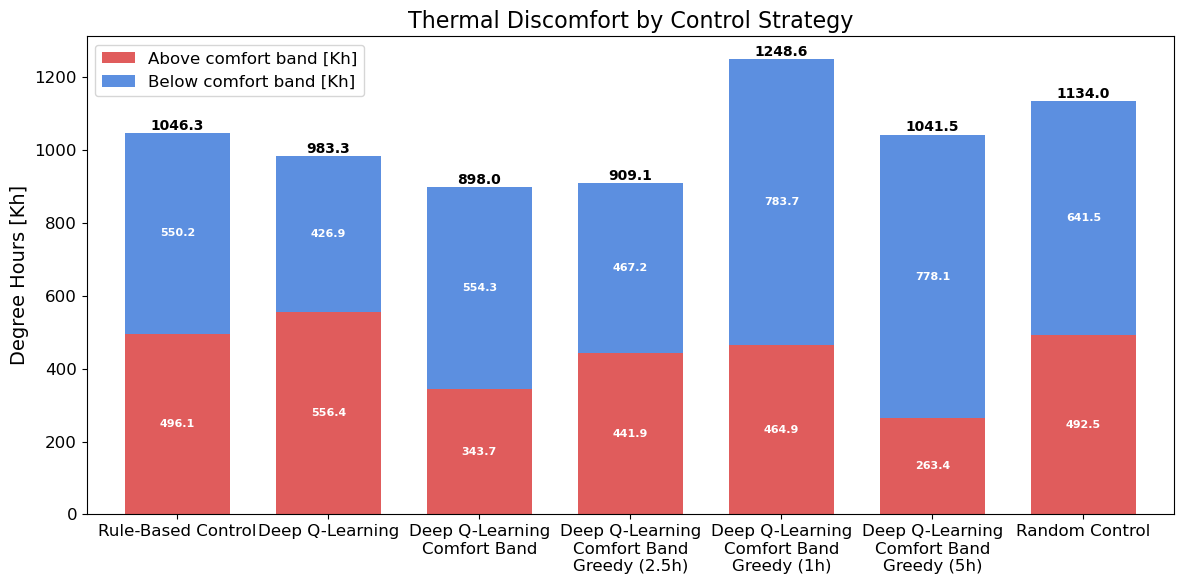

In [48]:
data["overheating"] = (data["operative_temperature"] - 21.5).clip(lower=0)
data["undercooling"] = (20.5 - data["operative_temperature"]).clip(lower=0)

overheating_kh = data.groupby("source")["overheating"].sum() / 12
undercooling_kh = data.groupby("source")["undercooling"].sum() / 12

summary = pd.DataFrame({
    "Above comfort band [Kh]": overheating_kh,
    "Below comfort band [Kh]": undercooling_kh,
}).sort_index()

summary.index = summary.index.map(name_to_label)

# plot
ax = summary.plot(kind="bar", stacked=True, figsize=(12, 6), color=["#e05c5c", "#5c8fe0"], width=0.7)

# annotate each segment
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt="%.1f", label_type="center", fontsize=8, color="white", fontweight="bold")

# annotate total on top
for i, total in enumerate(summary.sum(axis=1)):
    ax.text(i, total + 0.5, f"{total:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

plt.ylabel("Degree Hours [Kh]")
plt.xlabel("")
plt.title("Thermal Discomfort by Control Strategy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
# import torch
# import numpy as np
# from control_strategies.deep_rl import DQN, normalize_state, CONTROL_ACTION_VALUES, N_OBSERVATIONS, N_ACTIONS, MODEL_PATH, device

# # Load the saved model
# checkpoint = torch.load(MODEL_PATH, map_location=device)
# policy_net = DQN(N_OBSERVATIONS, N_ACTIONS).to(device)
# policy_net.load_state_dict(checkpoint["policy_net"])
# policy_net.eval()

# # Policy function for visualization
# def policy(state: dict) -> int:
#     with torch.no_grad():
#         action_index = policy_net(normalize_state(state)).max(1).indices.item()
#     return CONTROL_ACTION_VALUES[action_index]

In [50]:
# ranges = {
#     "operative_temperature":        np.linspace(15, 30, 50),
#     "dry_bulb_temperature":         np.linspace(15, 30, 50),
#     "total_horizontal_radiation":   np.linspace(0, 300, 50),
# }

# defaults = {
#     "operative_temperature":        21.0,
#     "dry_bulb_temperature":         25,
#     "total_horizontal_radiation":   200.0,
# }

# keys = list(ranges.keys())
# pairs = [(keys[i], keys[j]) for i in range(len(keys)) for j in range(i+1, len(keys))]

# fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# action_levels  = [-1.5, -0.5, 0.5, 1.5, 2.5]
# action_colors  = ["#5c8fe0", "#a0c4f1", "#f5f5f5", "#e05c5c"]
# action_labels  = {-1: "outside open", 0: "closed", 1: "inside open", 2: "both open"}

# axes_list = list(axes.flat)

# for ax, (x_key, y_key) in zip(axes_list, pairs):
#     X, Y = np.meshgrid(ranges[x_key], ranges[y_key])

#     actions = np.array([
#         policy({**defaults, x_key: x, y_key: y})
#         for x, y in zip(X.ravel(), Y.ravel())
#     ]).reshape(X.shape)

#     cf = ax.contourf(X, Y, actions, levels=action_levels, colors=action_colors)
#     ax.set_xlabel(x_key.replace("_", " "))
#     ax.set_ylabel(y_key.replace("_", " "))

#     fixed = {k: v for k, v in defaults.items() if k not in (x_key, y_key)}
#     fixed_str = ", ".join(f"{k.replace('_', ' ')}={v}" for k, v in fixed.items())
#     ax.set_title(fixed_str)

# cbar = fig.colorbar(cf, ax=axes_list, ticks=[-1, 0, 1, 2], fraction=0.02, pad=0.04)
# cbar.ax.set_yticklabels([action_labels[t] for t in [-1, 0, 1, 2]])

# plt.tight_layout()
# plt.show()